Đề tài cuối khóa: ABI99 - N3 - Nguyễn Thái Hòa, Nguyễn Thanh Phước

Phân tích dữ liệu vận hành và hành vi khách hàng trong dịch vụ gọi xe công nghệ – Trường hợp nghiên cứu bộ dữ liệu “NCR Ride Bookings”

PHẦN XỬ LÝ TIỀN DỮ LIỆU

1. Import một số thư viện để xử lý, làm sạch dữ liệu

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Đọc dữ liệu và những dữ liệu cần xử lý

2.1 Đọc dữ liệu và tổng quát về dữ liệu

In [2]:
#Đọc dữ liệu
df_ncr = pd.read_csv('dataset/ncr_ride_bookings.csv')

In [3]:
#Kiểm tra dữ liệu
df_ncr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [4]:
df_ncr

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,3/23/2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11/29/2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,8/23/2024,8:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,10/21/2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,9/16/2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,11/11/2024,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,11/24/2024,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,9/18/2024,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,10/5/2024,7:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [5]:
df_ncr.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

Xử lý tiền dữ liệu với những vấn đề sau:
1. Thay thế giá trị null của cột "Avg VTAT", "Avg CTAT" bằng giá trị median của cột chính nó
2. Thay thế giá trị null của cột "Cancelled Rides by Customer", "Cancelled Rides by Driver" bằng 0 (trong cột này đang có 2 giá trị là 1 tượng trưng cho hủy chuyến và 0 là không hủy chuyến) và chuyển type cột thành kiểu int
3. Chuyển hóa kiểu dữ liệu cột "Date", "Time"
4. Loại bỏ ký tự đặc biệt cột "Booking ID", "Customer ID"
5. Chuẩn hóa, thống nhất nhóm trạng thái cột "Booking Status"
6. Thay thế giá trị null trong cột "Reason for cancelling by Customer","Driver Cancellation Reason" dựa trên cột "Booking Status"
7. Thay thế giá trị null của cột "Incomplete Rides" bằng 0 (trong cột này đang có 2 giá trị là 1 tượng trưng cho có lỗi trong chuyến đi và 0 là không có lỗi trong chuyến đi) và chuyển type cột thành kiểu int
8. Thay thế giá trị null của cột "Incomplete Rides Reason" thành "No issue" dựa theo giá trị cột "Incomplete Rides" bằng 0
9. Thay thế giá trị null của cột "Payment Method" thành giá trị "Unknown"

2.2 Xử lý làm sạch dữ liệu

In [6]:
#1. Thay thế giá trị null của cột "Avg VTAT", "Avg CTAT" bằng giá trị mean của cột chính nó
df_ncr['Avg CTAT'] = df_ncr['Avg CTAT'].fillna(df_ncr['Avg CTAT'].median())
df_ncr['Avg VTAT'] = df_ncr['Avg VTAT'].fillna(df_ncr['Avg VTAT'].median())

In [7]:
'''2. Thay thế giá trị null của cột "Cancelled Rides by Customer", "Cancelled Rides by Driver" bằng 0 
(trong cột này đang có 2 giá trị là 1 tượng trưng cho hủy chuyến và 0 là không hủy chuyến) và chuyển type cột thành kiểu int'''
df_ncr['Cancelled Rides by Customer'] = df_ncr['Cancelled Rides by Customer'].fillna(0).astype(int)
df_ncr['Cancelled Rides by Driver'] = df_ncr['Cancelled Rides by Driver'].fillna(0).astype(int)

In [8]:
#3. Chuyển hóa kiểu dữ liệu cột "Date", "Time"
df_ncr['Date'] = pd.to_datetime(df_ncr['Date'], errors='coerce')
df_ncr['Time'] = pd.to_datetime(df_ncr['Time'],format='%H:%M:%S', errors='coerce').dt.time

In [9]:
#4. Loại bỏ ký tự đặc biệt cột "Booking ID", "Customer ID"
df_ncr['Booking ID'] = df_ncr['Booking ID'].astype(str).str.replace('"','').str.strip()
df_ncr['Customer ID'] = df_ncr['Customer ID'].astype(str).str.replace('"','').str.strip()

In [10]:
#5. Chuẩn hóa, thống nhất nhóm trạng thái cột "Booking Status"
#Quy chuẩn nhóm trạng thái
status_map = {
    'Completed':'Completed', #Nhóm thành công
    'Cancelled by Driver':'Cancelled','Cancelled by Customer':'Cancelled', #Nhóm hủy
    'Incomplete':'Incomplete','No Driver Found':'Incomplete'   #Nhóm không hoàn thành
}
df_ncr['Booking Status'] = df_ncr['Booking Status'].map(status_map)

In [11]:
#6. Thay thế giá trị null trong cột "Reason for cancelling by Customer","Driver Cancellation Reason" dựa trên cột "Booking Status"
df_ncr.loc[(df_ncr['Booking Status'] == 'Cancelled') & (df_ncr['Reason for cancelling by Customer'].isna())\
           ,'Reason for cancelling by Customer'] = 'No reason specified'
df_ncr['Reason for cancelling by Customer'] = df_ncr['Reason for cancelling by Customer'].fillna('Not Applicable')
df_ncr.loc[(df_ncr['Booking Status'] == 'Cancelled') & (df_ncr['Driver Cancellation Reason'].isna())\
           ,'Driver Cancellation Reason'] = 'No reason specified'
df_ncr['Driver Cancellation Reason'] = df_ncr['Driver Cancellation Reason'].fillna('Not Applicable')

In [12]:
'''7. Thay thế giá trị null của cột "Incomplete Rides" bằng 0 
(trong cột này đang có 2 giá trị là 1 tượng trưng cho có lỗi trong chuyến đi và 0 là không có lỗi trong chuyến đi) 
và chuyển type cột thành kiểu int'''
df_ncr['Incomplete Rides'] = df_ncr['Incomplete Rides'].fillna(0).astype(str)

In [13]:
#8. Thay thế giá trị null của cột "Incomplete Rides Reason" dựa theo giá trị cột "Incomplete Rides" 
df_ncr.loc[(df_ncr['Incomplete Rides'] == '0.0') & (df_ncr['Incomplete Rides Reason'].isna())\
           ,'Incomplete Rides Reason'] = 'No issue'

In [14]:
#9. Thay thế giá trị null của cột "Payment Method" thành giá trị "Canceled"
df_ncr['Payment Method'] = df_ncr['Payment Method'].fillna('Canceled')

In [15]:
#Xuất file df_ncr
#df_ncr.to_csv('ncr_ride_booking_cleaned.csv')

3. Xây dựng phép tính để EDA dữ liệu

3.1 Xây dựng RFM

In [16]:
df_ncr.head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,CNR5884300,Incomplete,CID1982111,eBike,Palam Vihar,Jhilmil,8.3,28.8,...,Not Applicable,0,Not Applicable,0.0,No issue,NaN,NaN,NaN,NaN,Canceled
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Not Applicable,0,Not Applicable,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Applicable,0,Not Applicable,0.0,No issue,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Applicable,0,Not Applicable,0.0,No issue,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Applicable,0,Not Applicable,0.0,No issue,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,...,Not Applicable,0,Not Applicable,0.0,No issue,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,Not Applicable,0,Not Applicable,0.0,No issue,640.0,41.24,4.0,4.1,UPI
7,2024-03-19,17:37:37,CNR6568000,Completed,CID8610436,Auto,Mayur Vihar,Cyber Hub,12.1,16.5,...,Not Applicable,0,Not Applicable,0.0,No issue,136.0,6.56,4.4,4.2,UPI
8,2024-09-14,12:49:09,CNR4510807,Incomplete,CID7873618,Go Sedan,Noida Sector 62,Noida Sector 18,8.3,28.8,...,Not Applicable,0,Not Applicable,0.0,No issue,NaN,NaN,NaN,NaN,Canceled
9,2024-12-16,19:06:48,CNR7721892,Incomplete,CID5214275,Auto,Rohini,Adarsh Nagar,6.1,26.0,...,Not Applicable,0,Not Applicable,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash


In [17]:
#Xây dựng RFM dựa trên những chuyến xe đã hoàn thành
df_completed = df_ncr[df_ncr['Booking Status'] == 'Completed'].copy()
df_completed

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Applicable,0,Not Applicable,0.0,No issue,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Applicable,0,Not Applicable,0.0,No issue,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Applicable,0,Not Applicable,0.0,No issue,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,...,Not Applicable,0,Not Applicable,0.0,No issue,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,Not Applicable,0,Not Applicable,0.0,No issue,640.0,41.24,4.0,4.1,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,Not Applicable,0,Not Applicable,0.0,No issue,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,Not Applicable,0,Not Applicable,0.0,No issue,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,Not Applicable,0,Not Applicable,0.0,No issue,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,Not Applicable,0,Not Applicable,0.0,No issue,333.0,45.54,4.1,3.7,UPI


In [18]:
#Lấy ngày gốc để tính Recency
reference_date = df_completed['Date'].max() + pd.Timedelta(days = 1)
# Tính R,F,M 
RFM_ncr = df_completed.groupby(by = 'Customer ID', as_index=False)\
        .agg(Recency = ('Date', lambda x: (reference_date - x.max()).days),
             Frequency = ('Booking ID','nunique'),
             Monetary = ('Booking Value','sum'))
#Tính điểm R,F,M
RFM_ncr['R_Score'] = pd.qcut(RFM_ncr['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
RFM_ncr['F_Score'] = pd.qcut(RFM_ncr['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
RFM_ncr['M_Score'] = pd.qcut(RFM_ncr['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
RFM_ncr['RFM'] = RFM_ncr['R_Score'].astype(str) + RFM_ncr['F_Score'].astype(str) + RFM_ncr['M_Score'].astype(str)
#Tạo segment - phân loại từng khách hàng theo RFM
def segment_rfm(row):
    # 1. Nhóm Tốt Nhất (Champions): R và F cao
    if row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Champions'
    # 2. Nhóm Tương lai (Potential Loyalists): R, F trung bình cao
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Potential Loyalists'
    # 3. Nhóm Khách hàng Mới (Recent Customers): R rất cao, F thấp
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'Recent Customers'
    # 4. Nhóm Nguy cơ Cao (At Risk): R trung bình/thấp, F cao (Họ từng mua nhiều nhưng đã lâu)
    elif row['R_Score'] <= 2 and row['R_Score'] <= 3 and row['F_Score'] >= 3:
        return 'At Risk'
    # 5. Nhóm Ngủ quên/Mất (Lost/Hibernating): R và F thấp
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost/Hibernating'
    # 6. Các trường hợp còn lại
    else:
        return 'Others'
RFM_ncr['Segment'] = RFM_ncr.apply(segment_rfm, axis=1)

In [19]:
#Xuất file RFM_ncr
#RFM_ncr.to_csv('rfm_completed.csv')

3.2 Xây dựng bảng Cohort

In [20]:
#Copy lại bảng ds chuyến đi thành công để xây dựng cohort
Cohort_com = df_completed.copy()
Cohort_com

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Applicable,0,Not Applicable,0.0,No issue,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Applicable,0,Not Applicable,0.0,No issue,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Applicable,0,Not Applicable,0.0,No issue,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,...,Not Applicable,0,Not Applicable,0.0,No issue,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,Not Applicable,0,Not Applicable,0.0,No issue,640.0,41.24,4.0,4.1,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,Not Applicable,0,Not Applicable,0.0,No issue,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,Not Applicable,0,Not Applicable,0.0,No issue,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,Not Applicable,0,Not Applicable,0.0,No issue,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,Not Applicable,0,Not Applicable,0.0,No issue,333.0,45.54,4.1,3.7,UPI


In [21]:
#Tạo cột "Cohort Month"
Cohort = Cohort_com.groupby('Customer ID').agg(CohortMonth = ('Date','min')).reset_index()

In [22]:
#Merge
Cohort_com = Cohort_com.merge(Cohort, on = 'Customer ID', how = 'left')
# Lấy tháng bắt đầu (ngày 1) của tháng hiện tại
def get_month(date):
    return date.to_period('M').to_timestamp('M').normalize()
# Áp dụng hàm chuẩn hóa cho cả Date và CohortMonth
Cohort_com['Date'] = Cohort_com['Date'].apply(get_month)
Cohort_com['CohortMonth'] = Cohort_com['CohortMonth'].apply(get_month)
#Tính "Cohort Index"
nam = Cohort_com['Date'].dt.year - Cohort_com['CohortMonth'].dt.year
thang = Cohort_com['Date'].dt.month - Cohort_com['CohortMonth'].dt.month
Cohort_com['CohortIndex'] = nam*12 + thang

In [23]:
#Tạo bảng cohort
CohortTable = Cohort_com.groupby(['CohortIndex','CohortMonth'])['Customer ID'].nunique().reset_index()
CohortTable['CohortMonth'] = CohortTable['CohortMonth'].dt.strftime('%Y-%m')
CohortTable

,CohortIndex,CohortMonth,Customer ID
0,0,2024-01,7951
1,0,2024-02,7358
2,0,2024-03,7943
3,0,2024-04,7600
4,0,2024-05,7874
...,...,...,...
73,9,2024-02,7
74,9,2024-03,7
75,10,2024-01,8
76,10,2024-02,7


In [24]:
#xây dựng ma trận cohort khách hàng duy trì
pivot = CohortTable.pivot(index = 'CohortMonth', columns = 'CohortIndex', values = 'Customer ID')
pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortMonth,,,,,,,,,,,,
2024-01,7951.0,7.0,3.0,13.0,8.0,4.0,4.0,8.0,4.0,2.0,8.0,5.0
2024-02,7358.0,4.0,9.0,1.0,3.0,4.0,7.0,11.0,7.0,7.0,7.0,NaN
2024-03,7943.0,7.0,8.0,4.0,5.0,9.0,9.0,6.0,7.0,7.0,NaN,NaN
2024-04,7600.0,10.0,11.0,6.0,10.0,7.0,5.0,8.0,6.0,NaN,NaN,NaN
2024-05,7874.0,8.0,6.0,2.0,7.0,4.0,8.0,5.0,NaN,NaN,NaN,NaN
2024-06,7725.0,3.0,6.0,4.0,9.0,9.0,5.0,NaN,NaN,NaN,NaN,NaN
2024-07,7892.0,6.0,10.0,6.0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,7728.0,3.0,7.0,6.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,7485.0,4.0,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\Acer\AppData\Local\Temp\ipykernel_6356\4206655967.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = rate.applymap(percent_formatter)


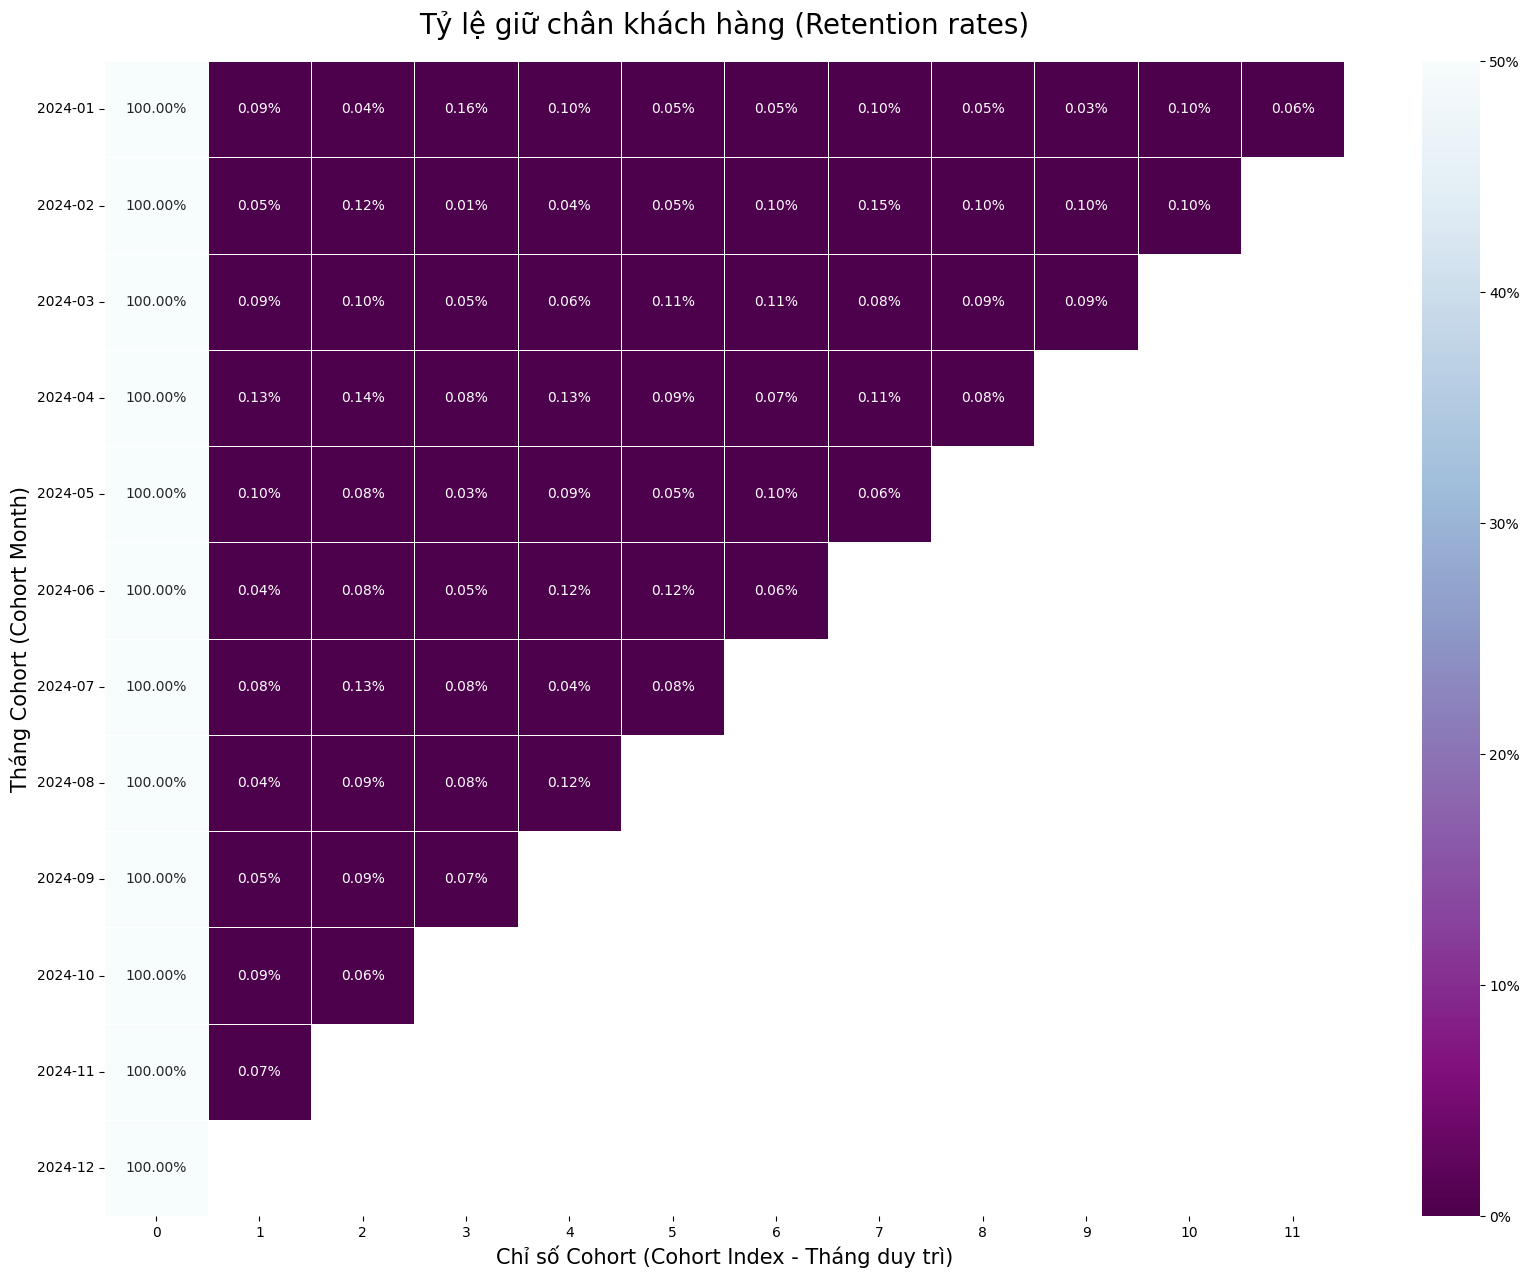

In [25]:
#Xây dựng tỉ lệ khách hàng retention
# Retention table
cohort_size = pivot.iloc[:,0]
retention = pivot.divide(cohort_size,axis=0) #axis=0 to ensure the divide along the row axis 
rate = retention.round(4) * 100 #to show the number as percentage
def percent_formatter(value):
    # Định dạng thành chuỗi, làm tròn 1 chữ số thập phân, và thêm ký hiệu %
    return f"{value:.2f}%"

# Tạo một mảng mới chứa các chuỗi đã được định dạng
annot_labels = rate.applymap(percent_formatter)
# Vẽ Heatmap
plt.figure(figsize=(20, 15)) # Tăng chiều cao (15) để các nhãn không bị dính
plt.title('Tỷ lệ giữ chân khách hàng (Retention rates)', fontsize=20, pad=20) # Tăng kích thước tiêu đề

sns.heatmap(
    data=rate,
    annot=annot_labels, #gán chuỗi
    fmt='s', # Hiển thị 1 chữ số thập phân (ví dụ: 10.0)
    
    # Chuẩn hóa thang màu Vmin/Vmax sang thang 0 - 50 (%)
    # Nếu Max Retention rate của bạn không quá 20%, bạn có thể chọn vmax nhỏ hơn (ví dụ: 20)
    vmin=0, 
    vmax=50, 
    cmap="BuPu_r", # Palette màu tím-xanh, đảo ngược
    linewidths=0.5, # Thêm đường viền mỏng giữa các ô
    linecolor='white', # Màu trắng để nổi bật các ô
    cbar_kws={'format': '%.0f%%'}, # Định dạng thanh màu (colorbar) thành %
)

# Thêm nhãn cho trục
plt.ylabel('Tháng Cohort (Cohort Month)', fontsize=15)
plt.xlabel('Chỉ số Cohort (Cohort Index - Tháng duy trì)', fontsize=15)

# Xoay nhãn trục Y ngang
plt.yticks(rotation=0)

plt.show()


***Tạo bảng thông tin cohort

In [26]:
CohortSize = cohort_size.reset_index()
CohortSize.rename(columns={0: 'CohortSize'}, inplace=True)
CohortSize

,CohortMonth,CohortSize
0,2024-01,7951.0
1,2024-02,7358.0
2,2024-03,7943.0
3,2024-04,7600.0
4,2024-05,7874.0
5,2024-06,7725.0
6,2024-07,7892.0
7,2024-08,7728.0
8,2024-09,7485.0
9,2024-10,7852.0


In [27]:
CohortTable = CohortTable.merge(CohortSize, on = 'CohortMonth', how = 'left')
CohortTable['Rate'] = (CohortTable['Customer ID']/CohortTable['CohortSize']).round(3)
CohortTable

,CohortIndex,CohortMonth,Customer ID,CohortSize,Rate
0,0,2024-01,7951,7951.0,1.000
1,0,2024-02,7358,7358.0,1.000
2,0,2024-03,7943,7943.0,1.000
3,0,2024-04,7600,7600.0,1.000
4,0,2024-05,7874,7874.0,1.000
...,...,...,...,...,...
73,9,2024-02,7,7358.0,0.001
74,9,2024-03,7,7943.0,0.001
75,10,2024-01,8,7951.0,0.001
76,10,2024-02,7,7358.0,0.001


In [28]:
#Xuất file bảng thông tin cohort và ma trận cohort
#CohortTable.to_csv('Cohort_completed.csv')
#pivot.to_csv('cohort_matrix.csv')

In [29]:
Cohort_com

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,CohortMonth,CohortIndex
0,2024-08-31,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Applicable,0.0,No issue,627.0,13.58,4.9,4.9,Debit Card,2024-08-31,0
1,2024-10-31,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Applicable,0.0,No issue,416.0,34.02,4.6,5.0,UPI,2024-10-31,0
2,2024-09-30,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Applicable,0.0,No issue,737.0,48.21,4.1,4.3,UPI,2024-09-30,0
3,2024-02-29,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,...,Not Applicable,0.0,No issue,316.0,4.85,4.1,4.6,UPI,2024-02-29,0
4,2024-06-30,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,Not Applicable,0.0,No issue,640.0,41.24,4.0,4.1,UPI,2024-06-30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92995,2024-11-30,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,Not Applicable,0.0,No issue,475.0,40.08,3.7,4.1,Uber Wallet,2024-11-30,0
92996,2024-11-30,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,Not Applicable,0.0,No issue,1093.0,21.31,4.8,5.0,UPI,2024-11-30,0
92997,2024-09-30,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,Not Applicable,0.0,No issue,852.0,15.93,3.9,4.4,Cash,2024-09-30,0
92998,2024-10-31,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,Not Applicable,0.0,No issue,333.0,45.54,4.1,3.7,UPI,2024-10-31,0


In [30]:
Cohort_com['Date'] = Cohort_com['Date'].dt.to_period('M').astype(str)
Cohort_com['CohortMonth'] = Cohort_com['CohortMonth'].dt.to_period('M').astype(str)

In [31]:
Cohort_com.to_csv('Table_cohortmonth.csv')

In [32]:
Cohort_fil = (Cohort_com['CohortMonth'] == '2024-01')
Cohort_fil.nunique()

2

In [33]:
Cohort_next = (Cohort_com['Date'] == '2024-02')
Cohort_next.nunique()

2

In [34]:
df_retained = Cohort_com[Cohort_fil & Cohort_next]
retained_customers_count = df_retained['Customer ID'].nunique()
retained_customers_count

7

In [35]:
df_retained

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,CohortMonth,CohortIndex
21224,2024-02,17:31:10,CNR9128093,Completed,CID2643961,Premier Sedan,Keshav Puram,Kashmere Gate,11.2,31.5,...,Not Applicable,0.0,No issue,465.0,31.63,4.5,4.3,UPI,2024-01,1
23423,2024-02,20:35:37,CNR4215521,Completed,CID3424848,Auto,Paschim Vihar,Chhatarpur,7.1,20.3,...,Not Applicable,0.0,No issue,290.0,4.24,4.0,4.4,UPI,2024-01,1
40215,2024-02,21:34:02,CNR9803306,Completed,CID4929908,Bike,Paschim Vihar,Bahadurgarh,5.0,28.2,...,Not Applicable,0.0,No issue,78.0,23.11,4.2,4.9,Cash,2024-01,1
44530,2024-02,18:38:01,CNR7737627,Completed,CID9136155,Go Sedan,Rajiv Nagar,Vaishali,6.9,21.5,...,Not Applicable,0.0,No issue,74.0,15.36,3.8,4.1,Debit Card,2024-01,1
45977,2024-02,05:13:44,CNR6204180,Completed,CID3038993,eBike,Arjangarh,Lal Quila,6.8,36.2,...,Not Applicable,0.0,No issue,703.0,46.55,3.2,4.9,Cash,2024-01,1
66441,2024-02,16:23:31,CNR1088509,Completed,CID4523979,Go Sedan,Punjabi Bagh,Laxmi Nagar,3.3,27.4,...,Not Applicable,0.0,No issue,142.0,39.22,3.6,4.4,UPI,2024-01,1
85186,2024-02,10:23:40,CNR1567094,Completed,CID9981018,Auto,IMT Manesar,Jahangirpuri,2.8,18.7,...,Not Applicable,0.0,No issue,722.0,19.49,4.6,3.2,UPI,2024-01,1
